# Desviación de un misil balístico por efecto Coriolis

**Alejandro Jaramillo Moreno**  
Instituto de Ciencias de la Atmósfera y Cambio Climático  
Universidad Nacional Autónoma de México

Supongamos que tenemos un misil balístico que es disparado en dirección este en la latitud de 43°N ($f \approx 10^{-4} \ \text{s}^{-1}$). Si el misil viaja 1000 km al este a una velocidad horizontal de $u_0 = 1000 \ \text{m s}^{-1}$, ¿cunto se deflectará el misil de su dirección este devido a la fuerza de Coriolis?

# Solución simplificada
# Ecuaciones de Coriolis en coordenadas locales

En un sistema de coordenadas locales $(x,y,z)$:

- $x$: dirección zonal (este-oeste)  
- $y$: dirección meridional (norte-sur)  
- $z$: vertical  

Las ecuaciones de movimiento debidas únicamente al efecto Coriolis son:

$$
\frac{du}{dt} = f v - 2\Omega \cos\phi \, w
$$

$$
\frac{dv}{dt} = -f u
$$

$$
\frac{dw}{dt} = 2\Omega \cos\phi \, u
$$

donde:

$$
f = 2\Omega \sin\phi
$$

es el parámetro de Coriolis.

---

## Simplificaciones para el problema del misil

Para este problema se hacen las siguientes aproximaciones:

- El movimiento es esencialmente **horizontal**, por lo que:
  
  $$
  w \approx 0
  $$

- Se desprecia el acoplamiento vertical del Coriolis:

  $$
  -2\Omega \cos\phi \, w \approx 0, \qquad 2\Omega \cos\phi \, u \approx 0
  $$

- Las ecuaciones se reducen a:

$$
\frac{du}{dt} = f v
$$

$$
\frac{dv}{dt} = -f u
$$

---

## Aproximación adicional

Supongamos que la desviación es pequeña. Por lo tanto, la velocidad zonal se podría considerar constante:

$$
u = u_0
$$


Bajo esta aproximación, la ecuación meridional se desacopla:

$$
\frac{dv}{dt} = -f u_0
$$

---

## Solución simplificada

Se asume:

- $u = u_0$ constante  
- $f$ constante  
- desviación pequeña  

La ecuación meridional es:

$$
\frac{dv}{dt} = -f u_0
$$

---

### Paso 1: Velocidad meridional

$$
v(t) = -f u_0 t
$$

---

### Paso 2: Posición meridional

$$
\frac{dy}{dt} = v = -f u_0 t
$$

$$
y(t) = -\frac{1}{2} f u_0 t^2
$$

---

### Paso 3: Tiempo de vuelo

$$
t = \frac{L}{u_0} = \frac{10^6}{10^3} = 1000 \ \text{s}
$$

---

### Paso 4: Sustitución

$$
y = -\frac{1}{2} (10^{-4})(1000)(1000)^2
$$

$$
y = -5 \times 10^4 \ \text{m} = -50 \ \text{km}
$$

---

### Resultado

$$
y = -50 \ \text{km}
$$

El misil se desvía **50 km hacia el sur**.

# Solución completa (sin asumir $u$ constante)

Sistema de ecuaciones:

$$
\frac{du}{dt} = f v
$$

$$
\frac{dv}{dt} = -f u
$$

$$
\frac{dx}{dt} = u, \qquad \frac{dy}{dt} = v
$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Omega = 7.292e-5 # rad s^-1

# latitud
lat_deg = 43.0             

# velocidad inicial hacia el este
u0 = 1000.0 # m s^-1, 
L = 1000e3 # m, 1000 km

In [2]:
lat = np.deg2rad(lat_deg)
f = 2.0*Omega*np.sin(lat)
# tiempo de vuelo igual al problema simplificado
t_end = L/u0 # s 

# vector de tiempo para evaluar y graficar
t = np.linspace(0, t_end, 1000)

print(f"f = {f:.6e} s^-1")
print(f"Tiempo de integración = {t_end:.1f} s = {t_end/60:.2f} min")

f = 9.946264e-05 s^-1
Tiempo de integración = 1000.0 s = 16.67 min


In [3]:
# Solución simplificada (u = u0 constante)
u_s = np.full_like(t, u0)
v_s = -f*u0*t

x_s = u0*t
y_s = -0.5*f*u0*(t**2)

In [4]:
# Solución del sistema completo
# du/dt = f*v
# dv/dt = -f*u
# dx/dt = u
# dy/dt = v

# Vamos a resolver numericamente este sistema completo de ecuaciones diferenciales usando `solve_ivp`.
# Este método integra numéricamente el sistema paso a paso en el tiempo, calculando cómo evolucionan 
# simultáneamente las variables $(x, y, u, v)$ a partir de sus derivadas.
# Por defecto, `solve_ivp` usa el método **Runge–Kutta de orden 4(5) (RK45)**, que es un esquema 
# explícito y adaptativo: ajusta automáticamente el tamaño de paso para mantener la precisión de la solución.

def sistema_completo(t, Y):
    x, y, u, v = Y
    dxdt = u
    dydt = v
    dudt = f*v
    dvdt = -f*u
    return [dxdt, dydt, dudt, dvdt]

# condiciones iniciales
Y0 = [0.0, 0.0, u0, 0.0]

sol = solve_ivp(sistema_completo, [0, t_end], Y0, t_eval=t)

print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.001e+00 ...  9.990e+02  1.000e+03]
        y: [[ 0.000e+00  1.001e+03 ...  9.974e+05  9.984e+05]
            [ 0.000e+00 -4.983e-02 ... -4.959e+04 -4.969e+04]
            [ 1.000e+03  1.000e+03 ...  9.951e+02  9.951e+02]
            [ 0.000e+00 -9.956e-02 ... -9.920e+01 -9.930e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 62
     njev: 0
      nlu: 0


In [5]:
x_c = sol.y[0]
y_c = sol.y[1]
u_c = sol.y[2]
v_c = sol.y[3]

# Resultados finales
print("Resultados finales")
print(f"Simplificado: x = {x_s[-1]/1000:.2f} km, y = {y_s[-1]/1000:.2f} km")
print(f"Completo:     x = {x_c[-1]/1000:.2f} km, y = {y_c[-1]/1000:.2f} km")
print(f"Diferencia en y = {y_c[-1] - y_s[-1]:.2f} m")

print("\nVelocidades finales")
print(f"Simplificado: u = {u_s[-1]:.2f} m/s, v = {v_s[-1]:.2f} m/s")
print(f"Completo:     u = {u_c[-1]:.2f} m/s, v = {v_c[-1]:.2f} m/s")

Resultados finales
Simplificado: x = 1000.00 km, y = -49.73 km
Completo:     x = 998.35 km, y = -49.69 km
Diferencia en y = 40.98 m

Velocidades finales
Simplificado: u = 1000.00 m/s, v = -99.46 m/s
Completo:     u = 995.06 m/s, v = -99.30 m/s


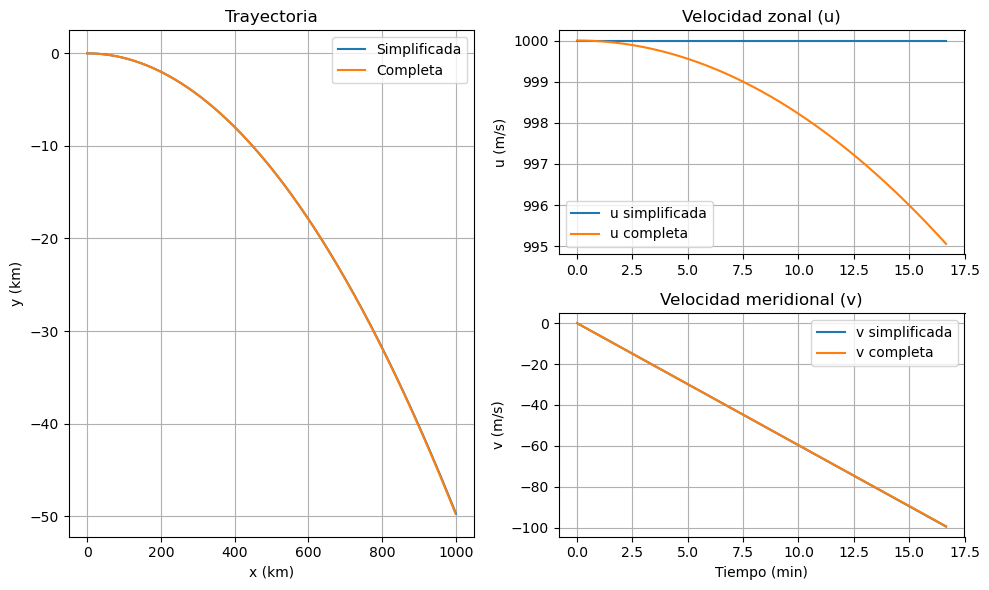

In [6]:
fig = plt.figure(figsize=(10, 6))

ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)

ax1.plot(x_s/1000, y_s/1000, label="Simplificada")
ax1.plot(x_c/1000, y_c/1000, label="Completa")

ax1.set_xlabel("x (km)")
ax1.set_ylabel("y (km)")
ax1.set_title("Trayectoria")
ax1.legend()
ax1.grid()


ax2 = plt.subplot2grid((2, 2), (0, 1))

ax2.plot(t/60, u_s, label="u simplificada")
ax2.plot(t/60, u_c, label="u completa")

ax2.set_ylabel("u (m/s)")
ax2.set_title("Velocidad zonal (u)")
ax2.legend()
ax2.grid()


ax3 = plt.subplot2grid((2, 2), (1, 1))

ax3.plot(t/60, v_s, label="v simplificada")
ax3.plot(t/60, v_c, label="v completa")

ax3.set_xlabel("Tiempo (min)")
ax3.set_ylabel("v (m/s)")
ax3.set_title("Velocidad meridional (v)")
ax3.legend()
ax3.grid()

plt.tight_layout()
plt.show()